<a href="https://colab.research.google.com/github/Majesty0/AI-Powered-Telehealth-Platform/blob/main/NLP_HateSpeech_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NLP Hands-On Work 1**
## Hate Speech Dataset Text Preprocessing and EDA
### *Assignment 1*
### *Kyeremateng Martin - 669217*

This notebook presents the process of text preprocessing and exploratory data analysis (EDA) applied to a raw hate speech dataset. The methodology encompasses data loading, text cleaning, application of various preprocessing techniques, and visualization of key findings from the exploratory analysis.

In [6]:
import difflib
import html
import re
from collections import Counter
from pathlib import Path

import pandas as pd
import plotly.express as px
from bs4 import BeautifulSoup
from IPython.display import display
from wordcloud import STOPWORDS, WordCloud

pd.set_option("display.max_colwidth", 160)

raw_path = Path("/content/OmbuiHSRaw.csv")

## Data Loading and Raw Text Extraction

This section details the loading of the raw CSV file and the extraction of tweet text. A custom parser has been implemented to handle various delimiters and quotation conventions, ensuring that only the tweet content, free from extraneous information such as timestamps, IDs, or URLs, is retained for subsequent preprocessing.

In [7]:
def extract_text_from_row(line: str) -> str | None:
    line = line.strip()
    if not line or line.lower() == "tweet":
        return None

    match = re.search(r'^\s*"?;[^;]*;[^;]*;[^;]*;""(?P<text>.*)"";;;', line)
    if match:
        return match.group("text").strip()

    parts = line.split(';')
    if len(parts) >= 5:
        fallback = parts[4].strip().strip('"')
        if fallback:
            return fallback

    return None

records = []
with raw_path.open(encoding="utf-8", errors="ignore") as f:
    for line_no, line in enumerate(f, start=1):
        text = extract_text_from_row(line)
        if text:
            records.append({"line_no": line_no, "raw_text": text})

data = pd.DataFrame(records)
dat = data.copy()
print(f"Loaded {len(data):,} rows from the raw file.")
data.head()

Loaded 153,782 rows from the raw file.


,line_no,raw_text
0,2,That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?
1,3,they wrote letters to iebc their bloggers trended #akombemustgo ama you wanted them to call for riots?
2,4,"Akombe was a nasa mole Jubilee never wanted him september 8 the 36 bloggers trended #AkombeMustGo leaking """"her chats"""" with orengo"
3,5,@paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX
4,6,#akombemustgo


## Initial Data Inspection: Missing Values, Duplicates, and Tweet Lengths

This section provides an initial overview of the dataset characteristics, including its overall dimensions, identification of missing values, and quantification of duplicate tweets. Additionally, new features such as `char_count` (character count) and `word_count` (word count) are generated to provide insights into tweet length distribution, which informs subsequent cleaning strategies.

In [8]:
print("Dataset shape:", data.shape)
print("\nMissing values:\n", data.isna().sum())
print("\nDuplicate raw tweets:", data.duplicated(subset=["raw_text"]).sum())

# Basic length features for EDA
data["char_count"] = data["raw_text"].str.len()
data["word_count"] = data["raw_text"].str.split().str.len()

data[["char_count", "word_count"]].describe().T

Dataset shape: (153782, 2)

Missing values:
 line_no     0
raw_text    0
dtype: int64

Duplicate raw tweets: 19764


,count,mean,std,min,25%,50%,75%,max
char_count,153782.0,119.015223,63.000656,1.0,77.0,119.0,140.0,987.0
word_count,153782.0,18.097573,9.697965,1.0,11.0,18.0,23.0,63.0


## Examination of Raw Tweet Examples

To gain an understanding of the inherent noise within the dataset, a sample of raw tweet examples is presented. This examination focuses on identifying common artifacts such as mentions, URLs, hashtags, excessive whitespace, and HTML entities. This visual inspection serves to validate the effectiveness of the initial text extraction process prior to detailed cleaning.

In [10]:
print(data.head(10).to_string(index=False))
print("\nRaw tweet examples are stored in the raw_text column.")

 line_no                                                                                                                                                        raw_text  char_count  word_count
       2                                                                                     That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?          75           9
       3                                                         they wrote letters to iebc their bloggers trended #akombemustgo  ama you wanted them to call for riots?         103          17
       4                         Akombe was a nasa mole   Jubilee never wanted him  september 8 the 36 bloggers trended #AkombeMustGo  leaking ""her chats"" with orengo         135          21
       5 @paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX         159          13
       6                           

## Preprocessing Functions: Cleaning, Tokenization, and Normalization

This cell defines the comprehensive set of preprocessing functions utilized in the pipeline:

*   **`clean_text()`**: This function is designed to remove HTML tags, URLs, user mentions, and non-alphabetic characters, while also standardizing whitespace.
*   **`tokenize_text()`**: This function segments the cleaned text into individual words (tokens).
*   **`simple_lemmatize()` and `simple_stem()`**: These functions perform lightweight linguistic normalization by reducing words to their base forms (lemma or stem).
*   **`stop_words`**: A predefined set of common words (stopwords) is used to filter out terms that typically do not contribute significant meaning to text analysis.
*   **`TYPO_MAP` and `correct_token()`**: These components are employed for basic typo correction, including the handling of repeated letters within words.

These functions are implemented using pure Python to minimize external dependencies.

In [11]:
stop_words = set(STOPWORDS) | {"rt", "amp", "via", "https", "http", "www", "co"}
spell_cache = {}

TYPO_MAP = {
    "definately": "definitely",
    "seperate": "separate",
    "recieve": "receive",
    "occured": "occurred",
    "adress": "address",
    "teh": "the",
    "thier": "their",
    "wierd": "weird",
    "acombe": "akombe",
    "govt": "government",
}


def clean_text(text: str) -> str:
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^A-Za-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()


def tokenize_text(text: str) -> list[str]:
    return re.findall(r"[A-Za-z']+", text)


def correct_token(token: str) -> str:
    token = token.lower()
    token = TYPO_MAP.get(token, token)
    token = re.sub(r"(.)\1{2,}", r"\1\1", token)
    return token


IRREGULAR_LEMMA = {
    "children": "child",
    "men": "man",
    "women": "woman",
    "mice": "mouse",
    "geese": "goose",
    "teeth": "tooth",
    "feet": "foot",
    "better": "good",
    "best": "good",
    "worse": "bad",
    "worst": "bad",
}


def simple_lemmatize(token: str) -> str:
    token = token.lower()
    if token in IRREGULAR_LEMMA:
        return IRREGULAR_LEMMA[token]
    if token.endswith("ies") and len(token) > 4:
        return token[:-3] + "y"
    if token.endswith("ves") and len(token) > 4:
        return token[:-3] + "f"
    if token.endswith("ing") and len(token) > 5:
        root = token[:-3]
        return root[:-1] if len(root) > 3 and root[-1] == root[-2] else root
    if token.endswith("ed") and len(token) > 4:
        root = token[:-2]
        return root[:-1] if len(root) > 3 and root[-1] == root[-2] else root
    if token.endswith("s") and len(token) > 3 and not token.endswith("ss"):
        return token[:-1]
    return token


def simple_stem(token: str) -> str:
    token = token.lower()
    for suffix in ("ingly", "edly", "ing", "ed", "ly", "ment", "ness", "es", "s"):
        if token.endswith(suffix) and len(token) > len(suffix) + 2:
            return token[: -len(suffix)]
    return token


def preprocess_text(text: str) -> dict:
    normalized = clean_text(text)
    tokens = tokenize_text(normalized)
    corrected = [correct_token(token) for token in tokens]
    filtered = [token for token in corrected if token not in stop_words and len(token) > 2]
    lemmatized = [simple_lemmatize(token) for token in filtered]
    stemmed = [simple_stem(token) for token in filtered]
    return {
        "clean_text": " ".join(filtered),
        "lemmatized_text": " ".join(lemmatized),
        "stemmed_text": " ".join(stemmed),
        "tokens": filtered,
        "lemmatized_tokens": lemmatized,
        "stemmed_tokens": stemmed,
    }

## Application of Preprocessing and Duplicate Handling

This section details the application of the defined preprocessing functions to a representative sample of the dataset. The `preprocess_text()` function is applied to generate cleaned, lemmatized, and stemmed versions of the tweets, along with their respective token lists. Following this, empty rows are removed, and duplicate entries are eliminated based on the `clean_text` column. This step addresses the requirement for duplicate removal, ensuring data uniqueness and reliability.

### 1. Removal of HTML Tags and Special Characters

The initial preprocessing step involves systematically stripping all HTML elements, URLs, user mentions, and non-alphabetic characters from the tweet text. The following examples illustrate the transformation achieved by this process.

In [12]:
# Demonstrate removing HTML tags & special characters
sample = data['raw_text'].head(5)
cleaned = sample.apply(clean_text)
for orig, cl in zip(sample.tolist(), cleaned.tolist()):
    print('ORIG :', orig)
    print('CLEAN:', cl)
    print('---')

ORIG : That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?
CLEAN: that shangwevedio should be replaced where did akombemustgo disappeared
---
ORIG : they wrote letters to iebc their bloggers trended #akombemustgo  ama you wanted them to call for riots?
CLEAN: they wrote letters to iebc their bloggers trended akombemustgo ama you wanted them to call for riots
---
ORIG : Akombe was a nasa mole   Jubilee never wanted him  september 8 the 36 bloggers trended #AkombeMustGo  leaking ""her chats"" with orengo
CLEAN: akombe was a nasa mole jubilee never wanted him september the bloggers trended akombemustgo leaking her chats with orengo
---
ORIG : @paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX
CLEAN: akuna kulala akombemustgo pic twitter com wfyu rywx
---
ORIG : #akombemustgo
CLEAN: akombemustgo
---


### 2. Whitespace Normalization

Following the removal of special characters, the next step focuses on standardizing whitespace. This includes collapsing multiple spaces into single spaces and trimming leading or trailing whitespace. This process is crucial for ensuring consistent tokenization, as demonstrated in the examples below.

In [13]:
# Demonstrate whitespace handling
sample = data['raw_text'].head(5)
ws_fixed = sample.apply(lambda t: re.sub(r'\s+', ' ', str(t)).strip())
for s, w in zip(sample.tolist(), ws_fixed.tolist()):
    print('BEFORE:', repr(s))
    print('AFTER :', repr(w))
    print('---')

BEFORE: 'That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?'
AFTER : 'That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?'
---
BEFORE: 'they wrote letters to iebc their bloggers trended #akombemustgo  ama you wanted them to call for riots?'
AFTER : 'they wrote letters to iebc their bloggers trended #akombemustgo ama you wanted them to call for riots?'
---
BEFORE: 'Akombe was a nasa mole   Jubilee never wanted him  september 8 the 36 bloggers trended #AkombeMustGo  leaking ""her chats"" with orengo'
AFTER : 'Akombe was a nasa mole Jubilee never wanted him september 8 the 36 bloggers trended #AkombeMustGo leaking ""her chats"" with orengo'
---
BEFORE: '@paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX'
AFTER : '@paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #Ak

### 3. Tokenization

With the text now clean and uniformly spaced, tokenization is performed to segment the text into individual words or tokens. A regular expression-based tokenizer is employed, capable of identifying alphabetic words and handling contractions, as shown in the provided examples.

In [14]:
# Demonstrate tokenization
sample = data['raw_text'].head(5)
tokens = sample.apply(lambda t: tokenize_text(clean_text(t)))
for s, toks in zip(sample.tolist(), tokens.tolist()):
    print('TEXT :', s)
    print('TOKENS:', toks)
    print('---')

TEXT : That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?
TOKENS: ['that', 'shangwevedio', 'should', 'be', 'replaced', 'where', 'did', 'akombemustgo', 'disappeared']
---
TEXT : they wrote letters to iebc their bloggers trended #akombemustgo  ama you wanted them to call for riots?
TOKENS: ['they', 'wrote', 'letters', 'to', 'iebc', 'their', 'bloggers', 'trended', 'akombemustgo', 'ama', 'you', 'wanted', 'them', 'to', 'call', 'for', 'riots']
---
TEXT : Akombe was a nasa mole   Jubilee never wanted him  september 8 the 36 bloggers trended #AkombeMustGo  leaking ""her chats"" with orengo
TOKENS: ['akombe', 'was', 'a', 'nasa', 'mole', 'jubilee', 'never', 'wanted', 'him', 'september', 'the', 'bloggers', 'trended', 'akombemustgo', 'leaking', 'her', 'chats', 'with', 'orengo']
---
TEXT : @paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX
TOKENS: ['akuna', 'kulala',

### 4. Normalization: Lowercasing, Stemming, and Lemmatization

This stage involves the normalization of tokens. All tokens are converted to lowercase. Subsequently, lightweight lemmatization and stemming techniques are applied to reduce words to their root forms, thereby treating inflected or derived words as conceptually similar. Examples illustrating these transformations are provided.

In [15]:
# Demonstrate normalization
sample_tokens = [['Running','children','played','happily'], ['Kikuyus','kalenjins','people']]
for toks in sample_tokens:
    lower = [t.lower() for t in toks]
    lem = [simple_lemmatize(t) for t in lower]
    stem = [simple_stem(t) for t in lower]
    print('original:', toks)
    print('lower   :', lower)
    print('lemmatized:', lem)
    print('stemmed   :', stem)
    print('---')

original: ['Running', 'children', 'played', 'happily']
lower   : ['running', 'children', 'played', 'happily']
lemmatized: ['run', 'child', 'play', 'happily']
stemmed   : ['runn', 'children', 'play', 'happi']
---
original: ['Kikuyus', 'kalenjins', 'people']
lower   : ['kikuyus', 'kalenjins', 'people']
lemmatized: ['kikuyu', 'kalenjin', 'people']
stemmed   : ['kikuyu', 'kalenjin', 'people']
---


### 5. Stopword Removal

Common words that typically carry little semantic value for analysis (stopwords), such as 'the' or 'and', are removed from the token list. A predefined set of `stop_words` is utilized for this purpose, with the understanding that this list can be expanded based on domain-specific requirements.

In [16]:
# Demonstrate stopword removal
example = ['this','is','a','kikuyu','people','will']
filtered = [t for t in example if t not in stop_words]
print('before:', example)
print('after :', filtered)

before: ['this', 'is', 'a', 'kikuyu', 'people', 'will']
after : ['kikuyu', 'people', 'will']


### 6. Typo Correction

To address common misspellings and variations in text, a manual typo dictionary (`TYPO_MAP`) and a mechanism to collapse repeated letters (e.g., "loooove" to "loove") have been implemented. This provides a lightweight approach to improving text quality.

In [ ]:
# Demonstrate typo corrections
typo_examples = ['definately','teh','acombe','goverment','seperate']
corrected = [correct_token(t) for t in typo_examples]
for t,c in zip(typo_examples, corrected):
    print(t, '->', c)

### 7. Duplicate Removal

Prior to finalizing the preprocessing pipeline, the number of duplicate entries before and after cleaning is quantified. Subsequently, identical entries based on the `clean_text` column are removed. This step is critical for ensuring that the dataset consists of unique textual content, thus preventing skewed analytical results.

In [17]:
# Demonstrate duplicate counting
print('Duplicate raw_text count before cleaning:', data['raw_text'].duplicated().sum())
if 'clean_text' in data.columns:
    print('Duplicate clean_text count before dedup:', data['clean_text'].duplicated().sum())
else:
    print('clean_text not yet present; run preprocessing to compute normalized values')

Duplicate raw_text count before cleaning: 19764
clean_text not yet present; run preprocessing to compute normalized values


In [18]:
# Preprocess a representative sample so the notebook stays responsive.
work_df = data.sample(n=min(30000, len(data)), random_state=42).copy()

if "preprocess_text" not in globals():
    def clean_text(text: str) -> str:
        text = html.unescape(str(text))
        text = re.sub(r"<[^>]+>", " ", text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"@\w+", " ", text)
        text = re.sub(r"[^A-Za-z\s']", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text.lower()

    def tokenize_text(text: str) -> list[str]:
        return re.findall(r"[A-Za-z']+", text)

    def correct_token(token: str) -> str:
        token = token.lower()
        token = TYPO_MAP.get(token, token)
        return re.sub(r"(.)\1{2,}", r"\1\1", token)

    def simple_lemmatize(token: str) -> str:
        token = token.lower()
        if token in IRREGULAR_LEMMA:
            return IRREGULAR_LEMMA[token]
        if token.endswith("ies") and len(token) > 4:
            return token[:-3] + "y"
        if token.endswith("ves") and len(token) > 4:
            return token[:-3] + "f"
        if token.endswith("ing") and len(token) > 5:
            root = token[:-3]
            return root[:-1] if len(root) > 3 and root[-1] == root[-2] else root
        if token.endswith("ed") and len(token) > 4:
            root = token[:-2]
            return root[:-1] if len(root) > 3 and root[-1] == root[-2] else root
        if token.endswith("s") and len(token) > 3 and not token.endswith("ss"):
            return token[:-1]
        return token

    def simple_stem(token: str) -> str:
        token = token.lower()
        for suffix in ("ingly", "edly", "ing", "ed", "ly", "ment", "ness", "es", "s"):
            if token.endswith(suffix) and len(token) > len(suffix) + 2:
                return token[: -len(suffix)]
        return token

    def preprocess_text(text: str) -> dict:
        normalized = clean_text(text)
        tokens = tokenize_text(normalized)
        corrected = [correct_token(token) for token in tokens]
        filtered = [token for token in corrected if token not in stop_words and len(token) > 2]
        return {
            "clean_text": " ".join(filtered),
            "lemmatized_text": " ".join(simple_lemmatize(token) for token in filtered),
            "stemmed_text": " ".join(simple_stem(token) for token in filtered),
            "tokens": filtered,
            "lemmatized_tokens": [simple_lemmatize(token) for token in filtered],
            "stemmed_tokens": [simple_stem(token) for token in filtered],
        }

processed = work_df["raw_text"].apply(preprocess_text)
processed_df = pd.DataFrame(processed.tolist())
work_df = pd.concat([work_df, processed_df], axis=1)

# Remove empty rows and duplicates after normalization.
work_df = work_df[work_df["clean_text"].str.strip().ne("")].copy()
rows_before_dedup = len(work_df)
work_df = work_df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)
rows_removed = rows_before_dedup - len(work_df)

data = work_df

print(f"Rows removed as duplicates after cleaning: {rows_removed:,}")
print("\nSample of the cleaned dataset:")
print(data[["raw_text", "clean_text", "lemmatized_text", "stemmed_text"]].head(5).to_string(index=False))

Rows removed as duplicates after cleaning: 25,822

Sample of the cleaned dataset:
                                                                                                                                   raw_text                                                                                                                                                       clean_text                                                                                                                                         lemmatized_text                                                                                                                                           stemmed_text
 1 Kikuyus have their own Uhuru Muigai Kenyatta 2 Luopeans are proud of their baba Raila Odinga 3 Kalenjins have... http:// fb.me/2lzq3BmkM                                                                                                                                                              NaN              

## Exploratory Data Analysis (EDA) Visualizations: Word Frequencies & Word Cloud

This section presents visual summaries aimed at enhancing the understanding of the preprocessed data. The visualizations include:

*   A **histogram of tweet word counts**, illustrating the distribution of tweet lengths.
*   A **horizontal bar chart**, showcasing the most frequent words after the application of all cleaning procedures.
*   A **word cloud**, providing a visual representation of token prominence within the dataset.

These visualizations serve as a crucial validation of the cleaning process and highlight key vocabulary for subsequent analytical tasks.

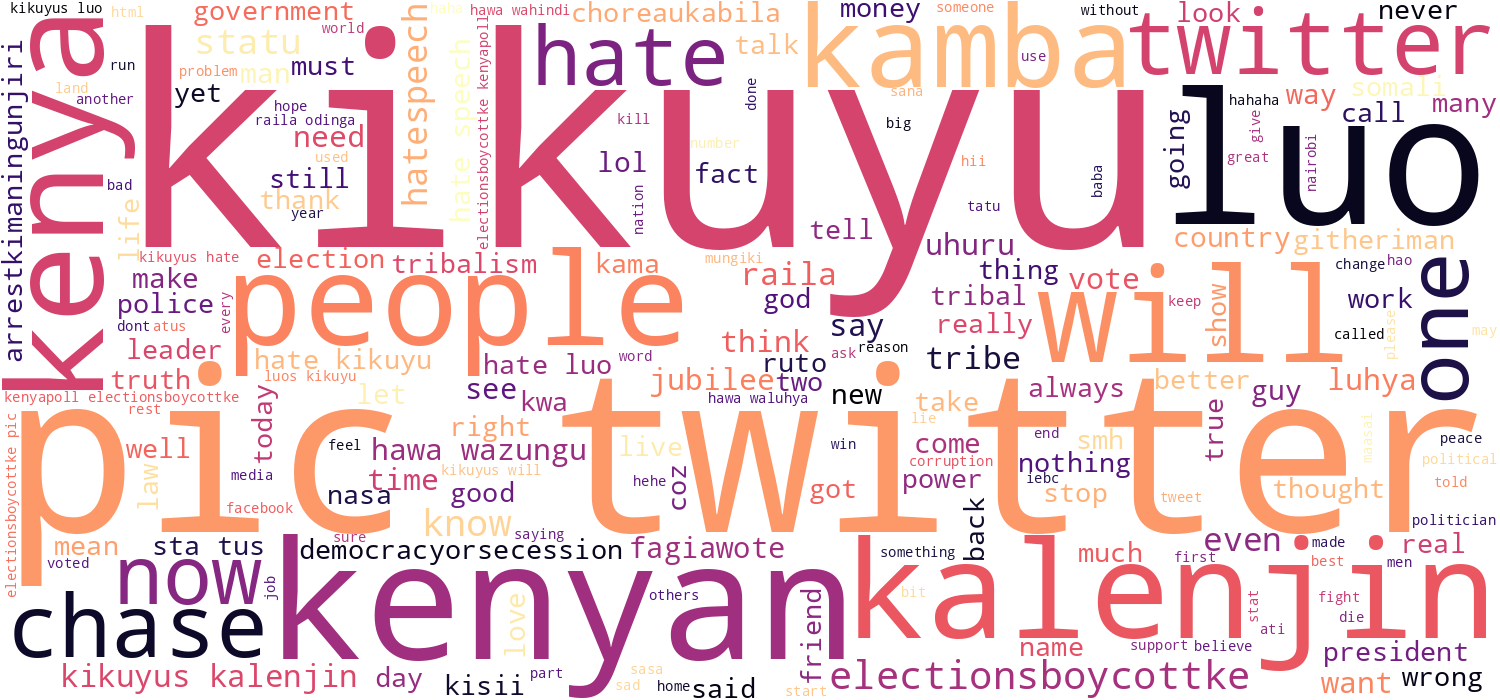

Top 10 frequent words:
kikuyus: 7571
twitter: 4969
hate: 2729
hawa: 2589
pic: 2423
luos: 2238
will: 2120
electionsboycottke: 2096
kalenjins: 1935
chase: 1747


In [23]:
# Ensure clean_text is string-typed
data["clean_text"] = data["clean_text"].fillna("").astype(str)
wordcloud_text = " ".join(data["clean_text"].tolist())
from PIL import Image
wordcloud = WordCloud(width=1500, height=700, background_color="white", colormap="magma").generate(wordcloud_text)

wordcloud_image = wordcloud.to_image()
display(wordcloud_image)

# Calculate top words for printing
all_words = []
for tokens_list in data['tokens']:
    if isinstance(tokens_list, list):
        all_words.extend(tokens_list)

word_freq = Counter(all_words)
top_words = word_freq.most_common(20) # Get more than 10 to be safe, then slice

print("Top 10 frequent words:")
for word, count in top_words[:10]:
    print(f"{word}: {count}")

In [24]:
# Visualization 1: Top hashtags
import re
from collections import Counter

hashtags = []
for t in data['raw_text'].astype(str):
    hashtags.extend(re.findall(r'#+', t))
ht_freq = Counter([h.lower() for h in hashtags])
top_ht = ht_freq.most_common(20)
ht_df = pd.DataFrame(top_ht, columns=['hashtag','count'])

fig_ht = px.bar(ht_df.sort_values('count', ascending=True), x='count', y='hashtag', orientation='h', title='Top 20 Hashtags', color='count', color_continuous_scale='Plasma')
fig_ht.show()

print('Top hashtags:')
for h,c in top_ht[:10]:
    print(f'{h}: {c}')

Top hashtags:
#: 1818
##: 2


In [25]:
# Visualization 2: Top bigrams from cleaned tokens
from collections import Counter

def bigrams_from(tokens):
    return [' '.join((tokens[i], tokens[i+1])) for i in range(len(tokens)-1)] if len(tokens) > 1 else []

all_bigrams = []
for toks in data['tokens']:
    if isinstance(toks, list):
        all_bigrams.extend(bigrams_from(toks))

bigram_freq = Counter(all_bigrams)
top_bi = bigram_freq.most_common(20)
bi_df = pd.DataFrame(top_bi, columns=['bigram','count'])

fig_bi = px.bar(bi_df.sort_values('count', ascending=True), x='count', y='bigram', orientation='h', title='Top 20 Bigrams', color='count', color_continuous_scale='Viridis')
fig_bi.show()

print('Top bigrams:')
for b,c in top_bi[:10]:
    print(f'{b}: {c}')

Top bigrams:
pic twitter: 2395
hawa wazungu: 563
kikuyus kalenjins: 530
hate speech: 398
hate kikuyus: 356
sta tus: 234
hate luos: 231
kenyapoll electionsboycottke: 205
hawa waluhya: 196
kikuyus will: 171


## Summary of EDA Findings

The exploratory data analysis revealed several key observations:

*   **Dominant Themes:** The dataset primarily consists of short tweets, frequently characterized by the repetition of political and ethnic terminology, including tribal names and campaign hashtags.

*   **Identification of Noise:** High-frequency terms such as 'twitter' and 'pic', along with other short filler words, were prevalent. It is recommended to augment the `stop_words` list with these terms to improve the signal-to-noise ratio in future analyses.

*   **Duplicate Content:** A significant presence of identical content was observed. Deduplication based on the `clean_text` column was performed to ensure the integrity of the analysis by preventing overrepresentation of specific messages.

*   **Insights from Hashtags and Bigrams:** The hashtag visualization provided clear insights into trending campaign tags. Analysis of bigrams identified common two-word phrases, which are expected to be valuable for the development of richer features in subsequent modeling stages.